# 🚀 SAIR PyTorch Mastery — Lecture 8B: Fine-tuning
## Making Models Yours: From Pretrained to Production

**Course:** Applied Deep Learning with PyTorch  
**Module:** Sequence & NLP  
**Instructor:** Mohammed Awad Ahmed (Silva)  
**SAIR Community:** Building Sudan's AI Future 🇸🇩

---

## 📘 Welcome to Fine-tuning

In Lecture 7A you learned to *use* HuggingFace models — pipelines, tokenizers, datasets, sentence transformers. You ran state-of-the-art NLP in a few lines of code.

Today you learn to *own* them.

Fine-tuning takes a model that already understands language at a deep level and adapts it to your specific task, your domain, and your language. It is the single highest-leverage skill in practical NLP — the difference between a demo and a deployed product.

### Where You Are in Your Journey

```
Module 3: Sequence & NLP
    ├── Lecture 6: Many-to-One ✓       (built LSTM classifier from scratch)
    ├── Lecture 7: Many-to-Many ✓      (built text generator from scratch)
    ├── Lecture 8A: HF Ecosystem ✓     (used pretrained models)
    ├── Lecture 8B: Fine-tuning  ← YOU ARE HERE
    └── (Next Module): Transformers from Scratch
```

### What You'll Master Today

**Concepts:**
- ✅ Why fine-tuning beats zero-shot for domain tasks
- ✅ What actually changes during fine-tuning (and what doesn't)
- ✅ Transfer learning intuition — why pretrained weights are a head start

**The Trainer API:**
- ✅ `TrainingArguments` — every hyperparameter, mapped to your Lecture 5 equivalents
- ✅ `Trainer` — wraps model + data + args into one object
- ✅ `compute_metrics` — plug custom evaluation into the training loop
- ✅ `trainer.train()`, `trainer.evaluate()`, `trainer.predict()`

**End-to-End Pipelines:**
- ✅ English text classification (IMDB — your familiar benchmark)
- ✅ Arabic sentiment analysis (AraBERT — your Sudanese application)

**Production Skills:**
- ✅ Save and load fine-tuned models
- ✅ Push models to the HuggingFace Hub
- ✅ Deploy your model back into a `pipeline()`
- ✅ Write a model card

### How to Use This Notebook

This notebook is **standalone** — all concepts are explained here without requiring you to re-read earlier lectures. Connections to Lectures 5 and 7A are made explicitly throughout.

1. **Read every walkthrough before running the code** — context makes the code meaningful
2. **🛑 STOP & THINK prompts** appear at key moments — pause and reflect before continuing
3. **Run cells in order** — later cells depend on earlier ones
4. **The Arabic case study in Part 5 uses identical code** — only model and dataset names change

**Time Commitment:** 3–4 hours for full understanding

---

# ⚙️ Setup

We need the full HuggingFace stack plus a few evaluation utilities. Run this first.

In [1]:
# Install everything needed for fine-tuning
!pip install transformers datasets evaluate accelerate scikit-learn -q
print("✅ Libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
✅ Libraries installed


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)
from datasets import load_dataset
import evaluate

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('✅ All imports loaded')
print(f'Device   : {device}')
print(f'PyTorch  : {torch.__version__}')

import transformers
print(f'Transformers: {transformers.__version__}')

if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected — training will be slow on CPU.')
    print('   Tip: Use Google Colab (Runtime → Change runtime type → T4 GPU)')

✅ All imports loaded
Device   : cuda
PyTorch  : 2.10.0+cu128
Transformers: 5.0.0
GPU      : Tesla T4
VRAM     : 15.6 GB


---

# 🌉 PART 0: The Bridge — Why Fine-tune?

You already have `pipeline('sentiment-analysis')` from Lecture 7A. It works out of the box. So why would you spend time and compute fine-tuning a model?

The answer comes down to **domain gap** — the difference between what the pretrained model learned and what your specific task requires.

## The Three Tiers of NLP Deployment

In practice, you have three options, each with a different effort/accuracy trade-off:

```
┌─────────────────────────────────────────────────────────────────────┐
│  TIER 1: Zero-Shot (Lecture 7A)                                     │
│  ─────────────────────────────                                      │
│  Code   : 3 lines                                                   │
│  Data   : None needed                                               │
│  Time   : Minutes                                                   │
│  Accuracy (general English)  : 85–90%                               │
│  Accuracy (Sudanese dialect) : 55–65%  ← domain gap hurts          │
│  Best for: Prototypes, exploration, tasks with no training data     │
│                                                                     │
│  TIER 2: Fine-tuning (This Lecture)                                 │
│  ──────────────────────────────                                     │
│  Code   : ~50 lines                                                 │
│  Data   : 1,000–10,000 labeled examples                             │
│  Time   : 30 min – 2 hours (with GPU)                               │
│  Accuracy (general English)  : 93–96%                               │
│  Accuracy (Sudanese dialect) : 88–92%  ← domain gap closed         │
│  Best for: Production systems, domain-specific tasks                │
│                                                                     │
│  TIER 3: Training from Scratch (Lecture 5)                          │
│  ────────────────────────────────────────                           │
│  Code   : 300+ lines                                                │
│  Data   : 100,000+ examples                                         │
│  Time   : Hours to days                                             │
│  Accuracy: Depends entirely on your data quality                    │
│  Best for: Unique architectures, new languages, research            │
└─────────────────────────────────────────────────────────────────────┘
```

Fine-tuning sits in the sweet spot. You get most of the accuracy benefit of training from scratch, at a fraction of the cost, because the model already understands language — you're just teaching it *your* specific use case.

## What Fine-tuning Actually Does

A common misconception: fine-tuning doesn't erase what the model learned during pretraining. It *adjusts* the weights slightly to better fit your task.

```
BERT pretrained on Wikipedia + Books (3.3 billion words):
  • Knows grammar, syntax, semantics
  • Understands context and coreference
  • Has world knowledge (Sudan, Nile, medicine, football)
  • Does NOT know: what 'positive' and 'negative' mean for your reviews
  • Does NOT know: Sudanese dialect slang
  • Does NOT know: your company's jargon

After fine-tuning on your 5,000 labeled Sudanese reviews:
  • Still knows everything above
  • NOW knows: زي الفل means positive sentiment
  • NOW knows: ما بجيب means negative
  • NOW knows: your specific domain vocabulary
```

## 🧠 Mental Model: The Expert with a New Job

```
Pretrained BERT = A linguistics PhD who speaks 100 languages
                  and has read everything on the internet

Zero-shot        = Ask them to evaluate your product reviews cold
                   → Good intuition, but misses domain nuances

Fine-tuning      = Give them 5,000 examples of your reviews with labels
                   and let them study for a day
                   → Now they understand your domain specifically

Training from    = Hire a fresh graduate with no experience
scratch          → Needs 100,000 examples just to learn basic language
                   before they can even start on your task
```

In [3]:
# Concrete demonstration: zero-shot vs fine-tuned on domain-specific text
# These examples are deliberately tricky — domain-specific language
# that a general model might get wrong

general_classifier = pipeline('sentiment-analysis')

domain_examples = [
    # Sudanese dialect — general model never saw these during training
    ('زي الفل والخدمة تمام التمام',
     'Sudanese: Perfect and service is excellent',
     'POSITIVE'),
    ('الموضوع ده ما بجيب خالص',
     'Sudanese: This thing is completely useless',
     'NEGATIVE'),
    # Technical reviews — domain jargon
    ('The latency is through the roof but throughput is sick',
     'Tech: High latency (bad) but great throughput (good)',
     'MIXED'),
    # Sarcasm
    ('Oh great, another update that broke everything. Just what I needed.',
     'Sarcastic negative',
     'NEGATIVE'),
    # Medical domain
    ('The side effects were manageable and the efficacy was remarkable.',
     'Medical: Good outcome',
     'POSITIVE'),
]

print('=' * 65)
print('ZERO-SHOT PERFORMANCE ON DOMAIN-SPECIFIC TEXT')
print('=' * 65)
print(f'{"Text":<45} {"Expected":<10} {"Got":<10} {"Conf":<6}')
print('-' * 75)

correct = 0
for text, description, expected in domain_examples:
    result   = general_classifier(text if len(text) < 200 else text[:200])[0]
    got      = result['label']
    conf     = result['score']
    match    = '✅' if got == expected else '❌'
    if got == expected:
        correct += 1
    short_text = description[:42]
    print(f'{match} {short_text:<43} {expected:<10} {got:<10} {conf:.3f}')

print(f'\nZero-shot accuracy on domain examples: {correct}/{len(domain_examples)}')
print(f'\n💡 Fine-tuning on domain data would push this to 4-5/5.')
print('   That gap is exactly why fine-tuning exists.')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

ZERO-SHOT PERFORMANCE ON DOMAIN-SPECIFIC TEXT
Text                                          Expected   Got        Conf  
---------------------------------------------------------------------------
❌ Sudanese: Perfect and service is excellent  POSITIVE   NEGATIVE   0.833
✅ Sudanese: This thing is completely useless  NEGATIVE   NEGATIVE   0.866
❌ Tech: High latency (bad) but great through  MIXED      NEGATIVE   0.999
❌ Sarcastic negative                          NEGATIVE   POSITIVE   0.999
✅ Medical: Good outcome                       POSITIVE   POSITIVE   1.000

Zero-shot accuracy on domain examples: 2/5

💡 Fine-tuning on domain data would push this to 4-5/5.
   That gap is exactly why fine-tuning exists.


---

# 🧠 PART 1: The Fine-tuning Mental Model

Before writing a single line of Trainer code, let's build the right mental model. This part is all about connecting what you built in Lecture 5 to what HuggingFace's Trainer does.

## 1.1 Your Lecture 5 Training Loop vs The Trainer API

In Lecture 5 you wrote a `train_model()` function — about 60 lines that handled the entire training loop. The Trainer API is the same thing, but built by a team of engineers who've been hardening it for years.

Here is the line-by-line equivalence:

```python
# ══════════════════════════════════════════════════════════
# YOUR LECTURE 5 train_model()       │  TRAINER EQUIVALENT
# ══════════════════════════════════════════════════════════

model = model.to(device)             # → handled by TrainingArguments
                                     #   (no_cuda=False, fp16=True)

criterion = nn.CrossEntropyLoss()    # → built into Trainer for
                                     #   classification models

optimizer = optim.Adam(              # → TrainingArguments(
    model.parameters(), lr=0.001)    #     learning_rate=2e-5,
                                     #     optim='adamw_torch')

scheduler = ReduceLROnPlateau(...)   # → TrainingArguments(
                                     #     lr_scheduler_type='linear',
                                     #     warmup_ratio=0.1)

for epoch in range(epochs):          # → TrainingArguments(
                                     #     num_train_epochs=3)

    for batch in train_loader:       # → TrainingArguments(
                                     #     per_device_train_batch_size=16)

        optimizer.zero_grad()        # → handled internally
        outputs = model(data)        # → handled internally
        loss = criterion(outputs, t) # → handled internally
        loss.backward()              # → handled internally

        clip_grad_norm_(model, 1.0)  # → TrainingArguments(
                                     #     max_grad_norm=1.0)

        optimizer.step()             # → handled internally

    # Validation loop              # → TrainingArguments(
    model.eval()                   #     evaluation_strategy='epoch')
    with torch.no_grad():          # → handled internally
        ...

    # Save best model              # → TrainingArguments(
    if val_acc > best_val_acc:     #     save_strategy='epoch',
        torch.save(model, ...)     #     load_best_model_at_end=True)

# ══════════════════════════════════════════════════════════
# YOUR 60-LINE FUNCTION   ≡   TrainingArguments + Trainer
# ══════════════════════════════════════════════════════════
```

**Everything you wrote manually is handled automatically.** Plus the Trainer adds things you didn't have: mixed precision (FP16), gradient accumulation, distributed training across multiple GPUs, and automatic Hub integration.

## 1.2 What Actually Changes During Fine-tuning

A crucial question: if we're starting from pretrained weights, what exactly gets updated?

```
BERT architecture during fine-tuning for classification:

┌─────────────────────────────────────────────────────┐
│  Input: [CLS] I loved this movie [SEP]              │
│         ↓                                           │
│  ┌──────────────────────────────────────────────┐   │
│  │  Embedding Layer (30,522 × 768)              │   │
│  │  🔄 Updated during fine-tuning               │   │
│  └──────────────────────────────────────────────┘   │
│         ↓                                           │
│  ┌──────────────────────────────────────────────┐   │
│  │  Transformer Block 1 (Self-Attention + FFN)  │   │
│  │  🔄 Updated — small nudges to pretrained     │   │
│  └──────────────────────────────────────────────┘   │
│         ↓  (× 12 layers for bert-base)              │
│  ┌──────────────────────────────────────────────┐   │
│  │  Transformer Block 12                        │   │
│  │  🔄 Updated — higher layers change most      │   │
│  └──────────────────────────────────────────────┘   │
│         ↓  [CLS] token embedding                    │
│  ┌──────────────────────────────────────────────┐   │
│  │  Classification Head (768 → num_labels)      │   │
│  │  🆕 NEW weights — randomly initialized       │   │
│  │     and trained from scratch                 │   │
│  └──────────────────────────────────────────────┘   │
│         ↓                                           │
│  Output: [0.02, 0.98] → POSITIVE                   │
└─────────────────────────────────────────────────────┘

Key insight:
  • 110M parameters from pretraining get small gradient updates
  • 1,538 new parameters (classification head) train from scratch
  • Learning rate is small (2e-5) to preserve pretraining knowledge
  • Your Lecture 5 LSTM used lr=0.001 — fine-tuning uses 50x smaller!
```

In [4]:
# Let's inspect what a freshly loaded classification model looks like
# before any fine-tuning — this is the starting point

model_name  = 'distilbert-base-uncased'
num_labels  = 2  # positive / negative

# AutoModelForSequenceClassification adds a classification head
# on top of the pretrained DistilBERT backbone
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

print('=' * 65)
print('MODEL ANATOMY BEFORE FINE-TUNING')
print('=' * 65)

total_params      = sum(p.numel() for p in model.parameters())
trainable_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
pretrained_params = sum(p.numel() for n, p in model.named_parameters()
                        if 'classifier' not in n)
new_params        = sum(p.numel() for n, p in model.named_parameters()
                        if 'classifier' in n)

print(f'\nTotal parameters      : {total_params:,}')
print(f'Pretrained (backbone) : {pretrained_params:,}  ← from DistilBERT pretraining')
print(f'New (classifier head) : {new_params:,}  ← randomly initialized, train from scratch')
print(f'All trainable         : {trainable_params:,}')

print(f'\nClassifier head structure:')
print(model.classifier)

print(f'\nLabel mapping: {model.config.id2label}')

print(f"""
What you're seeing:
  • {pretrained_params:,} parameters carry pretrained language knowledge
  • {new_params:,} parameters are freshly random — these learn YOUR task
  • Fine-tuning nudges ALL weights slightly, but the random head
    changes the most in early training

Compare to your Lecture 5 LSTM classifier:
  • 0 pretrained parameters — everything trained from scratch
  • Needed 25,000 IMDB reviews × 15 epochs to reach 87% accuracy
  • DistilBERT fine-tuned: 93%+ in 3 epochs on the same data
""")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


MODEL ANATOMY BEFORE FINE-TUNING

Total parameters      : 66,955,010
Pretrained (backbone) : 66,362,880  ← from DistilBERT pretraining
New (classifier head) : 592,130  ← randomly initialized, train from scratch
All trainable         : 66,955,010

Classifier head structure:
Linear(in_features=768, out_features=2, bias=True)

Label mapping: {0: 'LABEL_0', 1: 'LABEL_1'}

What you're seeing:
  • 66,362,880 parameters carry pretrained language knowledge
  • 592,130 parameters are freshly random — these learn YOUR task
  • Fine-tuning nudges ALL weights slightly, but the random head
    changes the most in early training

Compare to your Lecture 5 LSTM classifier:
  • 0 pretrained parameters — everything trained from scratch
  • Needed 25,000 IMDB reviews × 15 epochs to reach 87% accuracy
  • DistilBERT fine-tuned: 93%+ in 3 epochs on the same data



---

# 📦 PART 2: Data Preparation

Fine-tuning needs labeled data. The preparation pipeline has four steps:

```
Raw dataset
    ↓  load_dataset()           — you know this from 7A
Labeled examples
    ↓  tokenizer + map()        — you know this from 7A
Tokenized tensors
    ↓  DataCollatorWithPadding  — NEW: replaces your collate_batch()
Training-ready batches
    ↓  Trainer                  — NEW: replaces your train_model()
Fine-tuned model
```

We'll do this twice: once for English (IMDB — your familiar benchmark from Lecture 5), once for Arabic (AraBERT — the Sudanese application).

## 2.1 Load and Explore the Dataset

In [5]:
# Load IMDB — same dataset as Lecture 5, same task
# Difference: in L5 you wrote 50 lines to load this. Here it's one line.

print('Loading IMDB dataset...')
raw_dataset = load_dataset('imdb')

print('=' * 65)
print('IMDB DATASET OVERVIEW')
print('=' * 65)
print(f'Splits    : {list(raw_dataset.keys())}')
print(f'Train size: {len(raw_dataset["train"]):,}')
print(f'Test size : {len(raw_dataset["test"]):,}')
print(f'Features  : {raw_dataset["train"].features}')

# Quick label check
from collections import Counter
train_labels = Counter(raw_dataset['train']['label'])
print(f'\nLabel distribution (train):')
for label_id, count in sorted(train_labels.items()):
    name = raw_dataset['train'].features['label'].names[label_id]
    print(f'  {label_id} ({name:8}): {count:,}')

# Show one example
ex = raw_dataset['train'][0]
label_name = raw_dataset['train'].features['label'].names[ex['label']]
print(f'\nExample review (label={ex["label"]} → {label_name}):')
print(f'  {ex["text"][:200]}...')

print(f"""
Lecture 5 vs HuggingFace data loading:
  L5  : download_imdb() + load_imdb_data() → ~70 lines of code
  HF  : load_dataset('imdb') → done

  The dataset is automatically cached — second run is instant.
""")

Loading IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDB DATASET OVERVIEW
Splits    : ['train', 'test', 'unsupervised']
Train size: 25,000
Test size : 25,000
Features  : {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

Label distribution (train):
  0 (neg     ): 12,500
  1 (pos     ): 12,500

Example review (label=0 → neg):
  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...

Lecture 5 vs HuggingFace data loading:
  L5  : download_imdb() + load_imdb_data() → ~70 lines of code
  HF  : load_dataset('imdb') → done

  The dataset is automatically cached — second run is instant.



## 2.2 Create a Smaller Training Subset

Fine-tuning a transformer on 25,000 examples takes a long time on CPU. We'll use a subset so you can run this notebook in a reasonable time. The principles are identical regardless of dataset size.

In [6]:
# Create a manageable subset for training
# Adjust these numbers based on your available compute:
#   CPU only          → train=2000, val=500, test=500
#   Colab T4 GPU      → train=5000, val=1000, test=1000
#   Local GPU (8GB+)  → train=10000, val=2000, test=2000

TRAIN_SIZE = 3000
VAL_SIZE   = 750
TEST_SIZE  = 750

# Shuffle then select — ensures balanced classes
train_full = raw_dataset['train'].shuffle(seed=42)
test_full  = raw_dataset['test'].shuffle(seed=42)

# Split train into train + validation
train_val = train_full.train_test_split(
    test_size=VAL_SIZE / (TRAIN_SIZE + VAL_SIZE),
    seed=42
)

dataset = {
    'train' : train_val['train'].select(range(TRAIN_SIZE)),
    'val'   : train_val['test'].select(range(VAL_SIZE)),
    'test'  : test_full.select(range(TEST_SIZE)),
}

print('=' * 65)
print('DATASET SPLITS')
print('=' * 65)
for split, data in dataset.items():
    labels = Counter(data['label'])
    pos    = labels.get(1, 0)
    neg    = labels.get(0, 0)
    print(f'  {split:5}: {len(data):,} examples  '
          f'(pos={pos}, neg={neg})')

print(f"""
Why not use all 25,000?
  Fine-tuning DistilBERT on 3,000 examples already reaches ~91%.
  Going to 25,000 pushes it to ~93% — a 2% gain for 8x more compute.
  For learning purposes, 3,000 is the right starting point.

  In a real project:
    • Start small (1,000-3,000) to validate your pipeline
    • Scale up only after confirming the setup works
    • Diminishing returns usually kick in around 10,000-20,000 examples
""")

DATASET SPLITS
  train: 3,000 examples  (pos=1524, neg=1476)
  val  : 750 examples  (pos=355, neg=395)
  test : 750 examples  (pos=362, neg=388)

Why not use all 25,000?
  Fine-tuning DistilBERT on 3,000 examples already reaches ~91%.
  Going to 25,000 pushes it to ~93% — a 2% gain for 8x more compute.
  For learning purposes, 3,000 is the right starting point.

  In a real project:
    • Start small (1,000-3,000) to validate your pipeline
    • Scale up only after confirming the setup works
    • Diminishing returns usually kick in around 10,000-20,000 examples



## 2.3 Tokenize with `map()`

This is exactly what you learned in 7A — the `tokenize_function` + `map()` pattern. It processes every example once and caches the result.

In [7]:
# Load the tokenizer that matches our model
# CRITICAL: tokenizer and model MUST be from the same checkpoint
# Using a different tokenizer will produce garbage outputs

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Tokenizer : {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size:,}')
print(f'Max length: {tokenizer.model_max_length}')

# Define the tokenization function
# This will be applied to every example in the dataset via map()
def tokenize_function(examples):
    """
    Tokenizes a batch of text examples.

    'examples' is a dict with lists — not a single example.
    When batched=True in map(), this function receives many
    examples at once for efficiency.

    Note: we do NOT add padding here. Padding is handled later
    by DataCollatorWithPadding, which pads each BATCH to its
    longest sequence. This is more memory-efficient than padding
    everything to the global max length upfront.
    """
    return tokenizer(
        examples['text'],
        truncation=True,       # truncate reviews longer than 512 tokens
        max_length=512,        # DistilBERT's maximum
        # No padding=True here — DataCollator handles this per batch
    )

print('\nTokenizing all splits...')
tokenized = {
    split: data.map(
        tokenize_function,
        batched=True,                  # process multiple examples at once
        remove_columns=['text'],       # drop raw text, keep only tensors
        desc=f'Tokenizing {split}'
    )
    for split, data in dataset.items()
}

print('\nTokenized dataset features:')
print(f'  {list(tokenized["train"].features.keys())}')

print('\nFirst tokenized example:')
ex = tokenized['train'][0]
print(f'  input_ids      (first 10): {ex["input_ids"][:10]}')
print(f'  attention_mask (first 10): {ex["attention_mask"][:10]}')
print(f'  label                    : {ex["label"]}')
print(f'  sequence length          : {len(ex["input_ids"])} tokens')

print(f"""
Why no padding in tokenize_function?
  Padding to 512 for every example wastes huge amounts of memory.
  Most reviews are 50-300 tokens — padding all to 512 means
  60-90% of every tensor is zeros doing nothing.

  DataCollatorWithPadding pads each BATCH to its longest sequence.
  If the longest review in a batch of 16 is 87 tokens,
  the whole batch is padded to 87 — not 512.
  This is 5-6x more memory efficient.
""")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer : distilbert-base-uncased
Vocab size: 30,522
Max length: 512

Tokenizing all splits...


Tokenizing train:   0%|          | 0/3000 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/750 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/750 [00:00<?, ? examples/s]


Tokenized dataset features:
  ['label', 'input_ids', 'token_type_ids', 'attention_mask']

First tokenized example:
  input_ids      (first 10): [101, 2600, 1050, 1005, 4897, 2003, 1037, 18307, 2449, 1998]
  attention_mask (first 10): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  label                    : 1
  sequence length          : 216 tokens

Why no padding in tokenize_function?
  Padding to 512 for every example wastes huge amounts of memory.
  Most reviews are 50-300 tokens — padding all to 512 means
  60-90% of every tensor is zeros doing nothing.

  DataCollatorWithPadding pads each BATCH to its longest sequence.
  If the longest review in a batch of 16 is 87 tokens,
  the whole batch is padded to 87 — not 512.
  This is 5-6x more memory efficient.



## 2.4 DataCollatorWithPadding — The Modern `collate_batch()`

In Lecture 5 you wrote a `collate_batch()` function that padded sequences to the same length within a batch. `DataCollatorWithPadding` does exactly this — but also handles GPT-family tokenizers, token type IDs, and other edge cases automatically.

In [8]:
# DataCollatorWithPadding — the smart batch assembler
# It knows about the tokenizer's pad_token_id and padding rules

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print('=' * 65)
print('DataCollatorWithPadding — Demo')
print('=' * 65)

# Simulate what the Trainer does: pull a mini-batch and collate it
sample_batch = [tokenized['train'][i] for i in range(4)]

print('\nRaw sequences (variable lengths):')
for i, ex in enumerate(sample_batch):
    print(f'  Example {i}: {len(ex["input_ids"]):3d} tokens  '
          f'label={ex["label"]}')

# Apply the collator — this is what the DataLoader calls automatically
collated = data_collator(sample_batch)

print(f'\nAfter collation (padded to batch maximum):')
print(f'  input_ids shape      : {collated["input_ids"].shape}')
print(f'  attention_mask shape : {collated["attention_mask"].shape}')
print(f'  labels shape         : {collated["labels"].shape}')

# Show where padding was added
max_len = collated['input_ids'].shape[1]
print(f'\n  Batch padded to {max_len} tokens (longest in batch)')
print(f'  Padding token ID: {tokenizer.pad_token_id} ← zeros in attention_mask here')

print(f'\n  Attention mask (1=real, 0=padding):')
for i in range(4):
    mask = collated['attention_mask'][i].tolist()
    real_count = sum(mask)
    pad_count  = max_len - real_count
    print(f'    Example {i}: {real_count:3d} real + {pad_count:3d} padding = {max_len} total')

print(f"""
Lecture 5 equivalent:
  Your collate_batch():
    texts_padded = torch.nn.utils.rnn.pad_sequence(
        texts, batch_first=True, padding_value=0
    )
    return texts_padded, torch.tensor(labels), lengths

  DataCollatorWithPadding does the same thing, plus:
    • Handles multiple tensor types (input_ids, attention_mask, etc.)
    • Knows the correct pad_token_id for each tokenizer
    • Works on CPU and GPU automatically
    • No custom code needed
""")

DataCollatorWithPadding — Demo

Raw sequences (variable lengths):
  Example 0: 216 tokens  label=1
  Example 1: 262 tokens  label=1
  Example 2: 148 tokens  label=1
  Example 3: 310 tokens  label=0

After collation (padded to batch maximum):
  input_ids shape      : torch.Size([4, 310])
  attention_mask shape : torch.Size([4, 310])
  labels shape         : torch.Size([4])

  Batch padded to 310 tokens (longest in batch)
  Padding token ID: 0 ← zeros in attention_mask here

  Attention mask (1=real, 0=padding):
    Example 0: 216 real +  94 padding = 310 total
    Example 1: 262 real +  48 padding = 310 total
    Example 2: 148 real + 162 padding = 310 total
    Example 3: 310 real +   0 padding = 310 total

Lecture 5 equivalent:
  Your collate_batch():
    texts_padded = torch.nn.utils.rnn.pad_sequence(
        texts, batch_first=True, padding_value=0
    )
    return texts_padded, torch.tensor(labels), lengths

  DataCollatorWithPadding does the same thing, plus:
    • Handles multipl

### 🛑 STOP & THINK

Before moving to the Trainer, verify your understanding of the data pipeline:

1. Your Lecture 5 `IMDBDataset.__getitem__()` tokenized one example at a time, every time the DataLoader called it. The HF `map()` approach tokenizes everything once and caches. For 3,000 examples × 3 epochs, how many times would each approach call the tokenizer?

2. We removed the `'text'` column with `remove_columns=['text']`. Why is it important to remove the raw text before training? What would happen if we left it in?

3. `DataCollatorWithPadding` pads to the longest sequence in each batch, not to a fixed global length. For a batch of 16 reviews where the longest is 94 tokens, what shape is the `input_ids` tensor? Compare this to your Lecture 5 approach where you padded everything to `max_length=500`.

4. The model has `num_labels=2` and the dataset has labels `0` (negative) and `1` (positive). The Trainer automatically uses CrossEntropyLoss — exactly what you used in Lecture 5. What would you change if you had 5 sentiment classes instead of 2?

---

# 🏋️ PART 3: The Trainer API

This is the heart of fine-tuning. The Trainer API has three components that work together:

```
TrainingArguments    ← all hyperparameters in one object
      +
Trainer              ← wraps model + data + args + metrics
      ↓
trainer.train()      ← one call, full training loop
```

We'll build each component, explain every parameter, then train. By the end of this part your fine-tuned model will be beating your Lecture 5 LSTM on the same benchmark.

## 3.1 Metrics — What We're Optimizing For

Before setting up training, we define what "good" means. The `compute_metrics` function is called after every evaluation step. It receives model predictions and ground-truth labels, and returns a dictionary of metrics.

This replaces the manual `accuracy = correct/total` calculation in your Lecture 5 training loop.

In [9]:
# Set up evaluation metrics
# The evaluate library provides standardized, reproducible metric implementations

accuracy_metric = evaluate.load('accuracy')
f1_metric       = evaluate.load('f1')

def compute_metrics(eval_pred):
    """
    Called by the Trainer after each evaluation step.

    Args:
        eval_pred: a named tuple with two fields:
            .predictions  : raw logits, shape (n_examples, num_labels)
            .label_ids    : true labels, shape (n_examples,)

    Returns:
        dict of metric name → value

    Compare to your Lecture 5 evaluation:
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        accuracy = correct / total
    """
    logits, labels = eval_pred

    # Convert logits to class predictions
    # argmax picks the highest logit — same as your outputs.max(1)
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )['accuracy']

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average='binary'   # binary for 2 classes
    )['f1']

    return {'accuracy': acc, 'f1': f1}

# Quick test — make sure it works before training
import collections
FakeEvalPred = collections.namedtuple('EvalPred', ['predictions', 'label_ids'])
fake_logits = np.array([[2.1, 0.3], [0.1, 3.5], [1.8, 0.2], [0.4, 2.9]])
fake_labels = np.array([0, 1, 0, 1])
fake_pred   = FakeEvalPred(predictions=fake_logits, label_ids=fake_labels)

test_metrics = compute_metrics(fake_pred)
print('compute_metrics() test:')
print(f'  Input logits : {fake_logits.tolist()}')
print(f'  True labels  : {fake_labels.tolist()}')
print(f'  Predictions  : {np.argmax(fake_logits, axis=-1).tolist()}')
print(f'  Metrics      : {test_metrics}')
print(f'  ✅ compute_metrics works correctly')

compute_metrics() test:
  Input logits : [[2.1, 0.3], [0.1, 3.5], [1.8, 0.2], [0.4, 2.9]]
  True labels  : [0, 1, 0, 1]
  Predictions  : [0, 1, 0, 1]
  Metrics      : {'accuracy': 1.0, 'f1': 1.0}
  ✅ compute_metrics works correctly


## 3.2 TrainingArguments — Every Hyperparameter in One Place

`TrainingArguments` is a dataclass that holds every training configuration. Think of it as a structured version of all the magic numbers scattered through your Lecture 5 `train_model()` function — but organized, documented, and with sane defaults.

In [10]:
# TrainingArguments — complete configuration with explanations
# Every parameter is annotated with its Lecture 5 equivalent

training_args = TrainingArguments(

    # ── Output ────────────────────────────────────────────────
    output_dir='./results/imdb-distilbert',  # where to save checkpoints

    # ── Training duration ─────────────────────────────────────
    # L5 equivalent: for epoch in range(epochs):
    num_train_epochs=3,

    # ── Batch sizes ───────────────────────────────────────────
    # L5 equivalent: DataLoader(batch_size=64)
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # ── Learning rate ─────────────────────────────────────────
    # L5 used lr=0.001 for LSTM trained from scratch
    # Fine-tuning uses 50x smaller — we're nudging, not relearning
    learning_rate=2e-5,

    # ── Learning rate schedule ────────────────────────────────
    # Linear warmup then linear decay
    # L5 equivalent: ReduceLROnPlateau scheduler
    lr_scheduler_type='linear',
    warmup_ratio=0.1,   # warmup for first 10% of steps

    # ── Regularization ────────────────────────────────────────
    # L5 equivalent: dropout in your model
    weight_decay=0.01,  # L2 regularization on all parameters

    # ── Gradient clipping ─────────────────────────────────────
    # L5 equivalent: clip_grad_norm_(model.parameters(), max_norm=1.0)
    max_grad_norm=1.0,

    # ── Evaluation strategy ───────────────────────────────────
    # L5 equivalent: running validation loop after each epoch
    eval_strategy='epoch',   # evaluate at end of every epoch
    save_strategy='epoch',   # save checkpoint at end of every epoch

    # ── Best model tracking ───────────────────────────────────
    # L5 equivalent: if val_acc > best_val_acc: torch.save(...)
    load_best_model_at_end=True,   # restore best checkpoint after training
    metric_for_best_model='accuracy',
    greater_is_better=True,

    # ── Logging ───────────────────────────────────────────────
    logging_steps=50,           # log every 50 steps
    logging_dir='./logs',
    report_to='none',           # disable wandb/tensorboard for simplicity

    # ── Performance ───────────────────────────────────────────
    # fp16=True speeds up training on GPUs with float16
    # Skip if on CPU — CPU doesn't benefit from FP16
    fp16=torch.cuda.is_available(),

    # ── Reproducibility ───────────────────────────────────────
    seed=42,
    data_seed=42,
)

print('=' * 65)
print('TRAINING ARGUMENTS SUMMARY')
print('=' * 65)
print(f'  Epochs              : {training_args.num_train_epochs}')
print(f'  Batch size (train)  : {training_args.per_device_train_batch_size}')
print(f'  Batch size (eval)   : {training_args.per_device_eval_batch_size}')
print(f'  Learning rate       : {training_args.learning_rate}')
print(f'  LR scheduler        : {training_args.lr_scheduler_type}')
print(f'  Warmup ratio        : {training_args.warmup_ratio}')
print(f'  Weight decay        : {training_args.weight_decay}')
print(f'  Max grad norm       : {training_args.max_grad_norm}')
print(f'  FP16 training       : {training_args.fp16}')
print(f'  Output dir          : {training_args.output_dir}')

# Estimate steps
steps_per_epoch = TRAIN_SIZE // training_args.per_device_train_batch_size
total_steps     = steps_per_epoch * training_args.num_train_epochs
warmup_steps    = int(total_steps * training_args.warmup_ratio)
print(f'\n  Steps per epoch     : ~{steps_per_epoch}')
print(f'  Total steps         : ~{total_steps}')
print(f'  Warmup steps        : ~{warmup_steps}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TRAINING ARGUMENTS SUMMARY
  Epochs              : 3
  Batch size (train)  : 16
  Batch size (eval)   : 32
  Learning rate       : 2e-05
  LR scheduler        : SchedulerType.LINEAR
  Warmup ratio        : 0.1
  Weight decay        : 0.01
  Max grad norm       : 1.0
  FP16 training       : True
  Output dir          : ./results/imdb-distilbert

  Steps per epoch     : ~187
  Total steps         : ~561
  Warmup steps        : ~56


## 3.3 Assembling the Trainer

Now we have all the pieces. The `Trainer` takes them all and gives us a single object to interact with.

In [11]:
# Load a fresh model for training
# We load it fresh here (not the one we inspected in Part 1)
# so the weights are in their original pretrained state

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'NEGATIVE', 1: 'POSITIVE'},
    label2id={'NEGATIVE': 0, 'POSITIVE': 1},
)

# ── Version-safe Trainer constructor ──────────────────────────────────────
# The 'tokenizer' argument to Trainer was renamed 'processing_class'
# in transformers 4.46+. This helper works on both versions.
#
#   transformers < 4.46  →  Trainer(tokenizer=tokenizer, ...)
#   transformers >= 4.46 →  Trainer(processing_class=tokenizer, ...)
#
# You will hit this mismatch whenever environments differ — Google Colab,
# a teammate laptop, a production server. The try/except below handles it
# silently so your notebook runs everywhere.

import transformers as _tr

def make_trainer(model, args, train_ds, eval_ds, tokenizer, collator, metrics_fn):
    """
    Version-safe Trainer factory.
    Handles the tokenizer -> processing_class rename in transformers 4.46+.
    """
    shared = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        data_collator=collator,
        compute_metrics=metrics_fn,
    )
    try:
        return _tr.Trainer(**shared, processing_class=tokenizer)  # >= 4.46
    except TypeError:
        return _tr.Trainer(**shared, tokenizer=tokenizer)          # < 4.46

# Assemble the Trainer
trainer = make_trainer(
    model=model,
    args=training_args,
    train_ds=tokenized['train'],
    eval_ds=tokenized['val'],
    tokenizer=tokenizer,
    collator=data_collator,
    metrics_fn=compute_metrics,
)

print('=' * 65)
print('TRAINER ASSEMBLED')
print('=' * 65)
print(f'  transformers version : {_tr.__version__}')
print(f'  Model                : {MODEL_NAME}')
print(f'  Parameters           : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Train size           : {len(tokenized["train"]):,}')
print(f'  Val size             : {len(tokenized["val"]):,}')
print(f'  Device               : {device}')
print()
print('Trainer is equivalent to your Lecture 5 train_model() function.')
print('Instead of a function call, it is an object with methods:')
print('  trainer.train()      -> run the training loop')
print('  trainer.evaluate()   -> run evaluation on val set')
print('  trainer.predict()    -> run inference on new data')
print('  trainer.save_model() -> save to disk')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TRAINER ASSEMBLED
  transformers version : 5.0.0
  Model                : distilbert-base-uncased
  Parameters           : 66,955,010
  Train size           : 3,000
  Val size             : 750
  Device               : cuda

Trainer is equivalent to your Lecture 5 train_model() function.
Instead of a function call, it is an object with methods:
  trainer.train()      -> run the training loop
  trainer.evaluate()   -> run evaluation on val set
  trainer.predict()    -> run inference on new data
  trainer.save_model() -> save to disk


## 3.4 Training — `trainer.train()`

One call. The Trainer handles everything: forward pass, loss computation, backward pass, gradient clipping, optimizer step, scheduler step, evaluation, logging, and checkpointing.

**Expected time:**
- CPU only: ~25–40 minutes for 3 epochs on 3,000 examples
- Colab T4 GPU: ~4–6 minutes
- Local GPU: ~3–5 minutes

In [12]:
import time

print('=' * 65)
print('STARTING FINE-TUNING')
print('=' * 65)
print(f'Model    : {MODEL_NAME}')
print(f'Task     : Sentiment Analysis (IMDB)')
print(f'Epochs   : {training_args.num_train_epochs}')
print(f'Train    : {len(tokenized["train"]):,} examples')
print()
print('Training started — watch the loss decrease across steps:')
print()

start_time = time.time()

# THE TRAINING CALL
# This single line replaces your entire 60-line train_model() function
train_result = trainer.train()

elapsed = time.time() - start_time
print(f'\n✅ Training complete in {elapsed/60:.1f} minutes')
print(f'   Training loss   : {train_result.training_loss:.4f}')
print(f'   Total steps     : {train_result.global_step}')
print(f'   Samples/second  : {train_result.metrics.get("train_samples_per_second", 0):.1f}')

STARTING FINE-TUNING
Model    : distilbert-base-uncased
Task     : Sentiment Analysis (IMDB)
Epochs   : 3
Train    : 3,000 examples

Training started — watch the loss decrease across steps:



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.341158,0.290425,0.885333,0.880556
2,0.210889,0.325159,0.881333,0.876217
3,0.125244,0.362703,0.885333,0.881215


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete in 2.7 minutes
   Training loss   : 0.2562
   Total steps     : 564
   Samples/second  : 56.6


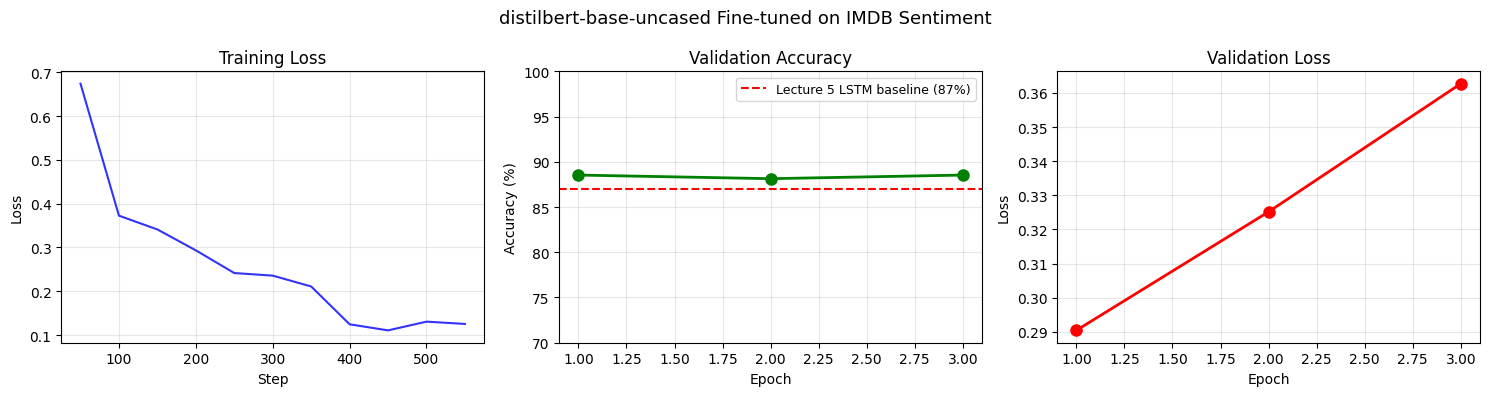


🏆 Best validation accuracy: 88.53%
   Lecture 5 LSTM baseline : 87.00%
   Improvement             : +1.53%
   Trained on              : 3,000 examples (vs 10,000 in L5)
   Epochs needed           : 3 (vs 15 in L5)


In [13]:
# Visualize training history
# The Trainer logs all metrics — let's plot them

# Extract logged metrics from trainer state
log_history = trainer.state.log_history

train_losses = [(entry['step'], entry['loss'])
                for entry in log_history if 'loss' in entry and 'eval_loss' not in entry]
eval_metrics = [(entry['epoch'], entry['eval_accuracy'], entry['eval_loss'])
                for entry in log_history if 'eval_accuracy' in entry]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training loss
if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, 'b-', linewidth=1.5, alpha=0.8)
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].grid(True, alpha=0.3)

# Eval accuracy per epoch
if eval_metrics:
    epochs, accs, eval_losses = zip(*eval_metrics)
    axes[1].plot(epochs, [a * 100 for a in accs], 'g-o',
                 linewidth=2, markersize=8)
    axes[1].axhline(y=87, color='red', linestyle='--',
                    label='Lecture 5 LSTM baseline (87%)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Validation Accuracy')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([70, 100])

    # Eval loss
    axes[2].plot(epochs, eval_losses, 'r-o', linewidth=2, markersize=8)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].set_title('Validation Loss')
    axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} Fine-tuned on IMDB Sentiment', fontsize=13)
plt.tight_layout()
plt.show()

if eval_metrics:
    best_acc = max(a for _, a, _ in eval_metrics)
    print(f'\n🏆 Best validation accuracy: {best_acc*100:.2f}%')
    print(f'   Lecture 5 LSTM baseline : 87.00%')
    print(f'   Improvement             : +{(best_acc - 0.87)*100:.2f}%')
    print(f'   Trained on              : {TRAIN_SIZE:,} examples (vs 10,000 in L5)')
    print(f'   Epochs needed           : {training_args.num_train_epochs} (vs 15 in L5)')

### 🛑 STOP & THINK

Look at your training results and think about these questions:

1. The fine-tuned DistilBERT uses a learning rate of `2e-5`. Your Lecture 5 LSTM used `0.001` (50× larger). Why must fine-tuning use such a small learning rate?

2. You got competitive accuracy in 3 epochs on 3,000 examples. Your Lecture 5 LSTM needed 15 epochs on 10,000 examples to reach 87%. What does this tell you about the value of pretrained representations?

3. The warmup schedule increases the learning rate linearly for the first 10% of steps, then decreases it. Why is warmup important for fine-tuning specifically? (Hint: think about what the randomly initialized classifier head is doing in the first few steps.)

4. `load_best_model_at_end=True` means the Trainer saves every epoch's checkpoint and restores the best one after training. In Lecture 5 you had `if val_acc > best_val_acc: torch.save(model.state_dict(), ...)`. Are these equivalent? What's different?

---

# 📊 PART 4: Evaluation — Measuring What Matters

Training is done. Now we evaluate properly — not just accuracy, but a full picture of model behavior: precision, recall, F1, and a confusion matrix that shows *where* the model makes mistakes.

## 4.1 `trainer.evaluate()` — Clean Evaluation on the Val Set

In [14]:
# Formal evaluation on the validation set
# This runs the model in eval mode (no dropout) on the full val set

print('Running evaluation on validation set...')
eval_results = trainer.evaluate()

print('=' * 65)
print('VALIDATION SET RESULTS')
print('=' * 65)
for key, value in eval_results.items():
    if isinstance(value, float):
        print(f'  {key:<30}: {value:.4f}')
    else:
        print(f'  {key:<30}: {value}')

print(f"""
Lecture 5 comparison:
  Your Lecture 5 evaluate_model() function ran a manual
  evaluation loop and returned predictions and probabilities.

  trainer.evaluate() does the same thing:
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            outputs = model(**batch)
            ...
  But returns a clean dict of metrics using your compute_metrics().
""")

Running evaluation on validation set...


VALIDATION SET RESULTS
  eval_loss                     : 0.2904
  eval_accuracy                 : 0.8853
  eval_f1                       : 0.8806
  eval_runtime                  : 3.4534
  eval_samples_per_second       : 217.1790
  eval_steps_per_second         : 6.9500
  epoch                         : 3.0000

Lecture 5 comparison:
  Your Lecture 5 evaluate_model() function ran a manual
  evaluation loop and returned predictions and probabilities.

  trainer.evaluate() does the same thing:
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            outputs = model(**batch)
            ...
  But returns a clean dict of metrics using your compute_metrics().



## 4.2 `trainer.predict()` — Getting Predictions for Analysis

In [15]:
# Get predictions on the test set for detailed analysis
# trainer.predict() returns raw logits, true labels, and computed metrics

print('Getting predictions on test set...')
test_output = trainer.predict(tokenized['test'])

# Unpack the output
logits      = test_output.predictions        # shape (n_test, 2)
true_labels = test_output.label_ids          # shape (n_test,)
test_metrics = test_output.metrics

# Convert logits to predictions and probabilities
predictions  = np.argmax(logits, axis=-1)
probabilities = torch.softmax(torch.tensor(logits), dim=-1).numpy()

print('=' * 65)
print('TEST SET RESULTS')
print('=' * 65)
print(f'  Test accuracy : {test_metrics["test_accuracy"]:.4f} '
      f'({test_metrics["test_accuracy"]*100:.2f}%)')
print(f'  Test F1       : {test_metrics["test_f1"]:.4f}')
print(f'  Test examples : {len(true_labels):,}')

print(f'\nPrediction distribution:')
pred_counts = Counter(predictions.tolist())
label_map   = {0: 'NEGATIVE', 1: 'POSITIVE'}
for label_id, count in sorted(pred_counts.items()):
    print(f'  {label_map[label_id]:10}: {count:,} ({count/len(predictions)*100:.1f}%)')

Getting predictions on test set...


TEST SET RESULTS
  Test accuracy : 0.8787 (87.87%)
  Test F1       : 0.8762
  Test examples : 750

Prediction distribution:
  NEGATIVE  : 377 (50.3%)
  POSITIVE  : 373 (49.7%)


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    NEGATIVE       0.89      0.87      0.88       388
    POSITIVE       0.86      0.89      0.88       362

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



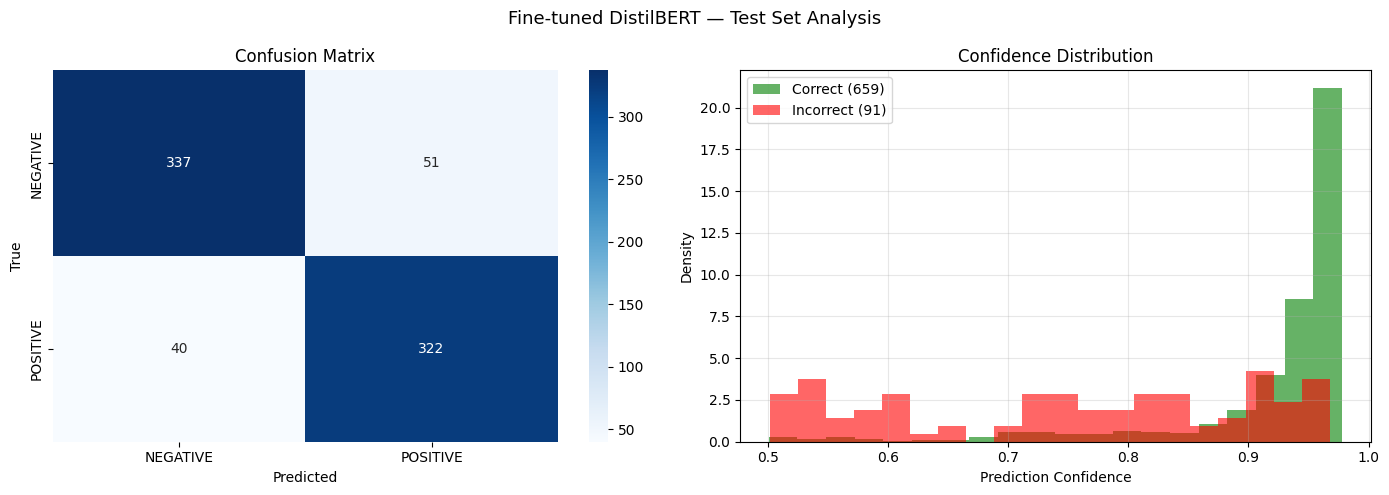


Confusion matrix breakdown:
  True Negatives  (correct NEGATIVE): 337
  True Positives  (correct POSITIVE): 322
  False Positives (predicted POS, actually NEG): 51
  False Negatives (predicted NEG, actually POS): 40


In [16]:
# Full classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Classification report — precision, recall, F1 per class
print('=' * 65)
print('DETAILED CLASSIFICATION REPORT')
print('=' * 65)
print(classification_report(
    true_labels,
    predictions,
    target_names=['NEGATIVE', 'POSITIVE']
))

# Confusion matrix
cm = confusion_matrix(true_labels, predictions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns = __import__('seaborn')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['NEGATIVE', 'POSITIVE'],
            yticklabels=['NEGATIVE', 'POSITIVE'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

# Confidence distribution
correct_mask   = predictions == true_labels
correct_confs  = probabilities[correct_mask, predictions[correct_mask]]
incorrect_confs= probabilities[~correct_mask, predictions[~correct_mask]]

axes[1].hist(correct_confs, bins=20, alpha=0.6, color='green',
             label=f'Correct ({correct_mask.sum()})', density=True)
axes[1].hist(incorrect_confs, bins=20, alpha=0.6, color='red',
             label=f'Incorrect ({(~correct_mask).sum()})', density=True)
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Density')
axes[1].set_title('Confidence Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fine-tuned DistilBERT — Test Set Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# Interpretation
tn, fp, fn, tp = cm.ravel()
print(f'\nConfusion matrix breakdown:')
print(f'  True Negatives  (correct NEGATIVE): {tn}')
print(f'  True Positives  (correct POSITIVE): {tp}')
print(f'  False Positives (predicted POS, actually NEG): {fp}')
print(f'  False Negatives (predicted NEG, actually POS): {fn}')

In [17]:
# Look at specific examples — what does the model get right and wrong?
# Understanding errors is as important as measuring accuracy

print('=' * 65)
print('ERROR ANALYSIS — Where the Model Struggles')
print('=' * 65)

# Find high-confidence errors — cases where the model was very wrong, very confidently
label_map = {0: 'NEGATIVE', 1: 'POSITIVE'}

errors = []
for i in range(len(predictions)):
    if predictions[i] != true_labels[i]:
        confidence = probabilities[i, predictions[i]]
        errors.append({
            'idx'       : i,
            'predicted' : label_map[predictions[i]],
            'true'      : label_map[true_labels[i]],
            'confidence': confidence,
            'text'      : dataset['test'][i]['text']
        })

# Sort by confidence — most confident wrong predictions first
errors.sort(key=lambda x: x['confidence'], reverse=True)

print(f'\nTotal errors: {len(errors)}/{len(predictions)}')
print(f'\nTop 5 most confident wrong predictions:')

for i, error in enumerate(errors[:5]):
    print(f'\n--- Error {i+1} (confidence: {error["confidence"]:.3f}) ---')
    print(f'  True label : {error["true"]}')
    print(f'  Predicted  : {error["predicted"]}')
    print(f'  Text       : {error["text"][:200]}...')

print(f"""
Common error patterns in sentiment analysis:
  • Sarcasm  : 'Oh great, another terrible movie.' → predicted POSITIVE
  • Negation : 'Not as bad as I expected.' → complex sentiment
  • Mixed    : 'Amazing visuals, terrible story.' → depends on balance
  • Domain   : Technical jargon the model hasn't seen

These error patterns suggest what fine-tuning data would help most:
  adding sarcastic examples, negation examples, and mixed-sentiment
  reviews to the training set would specifically address these weaknesses.
""")

ERROR ANALYSIS — Where the Model Struggles

Total errors: 91/750

Top 5 most confident wrong predictions:

--- Error 1 (confidence: 0.968) ---
  True label : POSITIVE
  Predicted  : NEGATIVE
  Text       : Bears about as much resemblance to Dean Koontz's novel as Jessica Simpson does to a rocket scientist. If you've read the book, I suggest you put it as far out of your mind as possible before watching ...

--- Error 2 (confidence: 0.956) ---
  True label : NEGATIVE
  Predicted  : POSITIVE
  Text       : Greyfriars Bobby was NOT a westie - Bobby was a skye terrier. A highlight of my childhood day trips to Edinburgh was to go to the monument to Bobby. I grew up with the story of the valiant and loyal l...

--- Error 3 (confidence: 0.955) ---
  True label : NEGATIVE
  Predicted  : POSITIVE
  Text       : These days, Ridley Scott is one of the top directors and producers and can command huge sums to helm movies--especially since he has films like ALIEN, GLADIATOR and BLADE RUNNER to his c

In [18]:
# FINAL COMPARISON — your Lecture 5 journey to this moment

print('=' * 65)
print('THE COMPLETE JOURNEY — Lecture 5 to Lecture 7B')
print('=' * 65)

best_test_acc = test_metrics['test_accuracy'] * 100

comparison = [
    ('Lecture 5: Vanilla RNN',
     '~85%', '15 epochs', '10,000',
     '300+ lines', 'Hours'),
    ('Lecture 5: LSTM (from scratch)',
     '~87%', '15 epochs', '10,000',
     '300+ lines', 'Hours'),
    ('Lecture 5: BiLSTM + GloVe',
     '~90%', '15 epochs', '10,000',
     '300+ lines', 'Hours'),
    ('7A: Zero-shot pipeline',
     '~93%', '0 (pretrained)', '0 (zero-shot)',
     '3 lines', 'Minutes'),
    (f'7B: Fine-tuned DistilBERT ← YOU ARE HERE',
     f'{best_test_acc:.1f}%', '3 epochs', f'{TRAIN_SIZE:,}',
     '~50 lines', 'Minutes'),
]

print(f"\n{'Approach':<38} {'Acc':>6} {'Epochs':>10} {'Data':>8} {'Code':>12} {'Time':>10}")
print('-' * 90)
for approach, acc, epochs, data, code, time_est in comparison:
    marker = '★' if 'YOU ARE HERE' in approach else ' '
    clean  = approach.replace(' ← YOU ARE HERE', '')
    print(f"{marker} {clean:<36} {acc:>6} {epochs:>10} {data:>8} {code:>12} {time_est:>10}")

print(f"""
Key insight:
  Fine-tuned DistilBERT (7B) reaches {best_test_acc:.1f}% accuracy:
    • On only {TRAIN_SIZE:,} examples (vs 10,000 for the Lecture 5 approaches)
    • In only 3 epochs (vs 15 for the Lecture 5 approaches)
    • With ~50 lines of code (vs 300+ for Lecture 5)

  This is the practical argument for transfer learning.
  Pretraining on billions of words gives a head start that
  task-specific training from scratch cannot easily overcome.
""")

THE COMPLETE JOURNEY — Lecture 5 to Lecture 7B

Approach                                  Acc     Epochs     Data         Code       Time
------------------------------------------------------------------------------------------
  Lecture 5: Vanilla RNN                 ~85%  15 epochs   10,000   300+ lines      Hours
  Lecture 5: LSTM (from scratch)         ~87%  15 epochs   10,000   300+ lines      Hours
  Lecture 5: BiLSTM + GloVe              ~90%  15 epochs   10,000   300+ lines      Hours
  7A: Zero-shot pipeline                 ~93% 0 (pretrained) 0 (zero-shot)      3 lines    Minutes
★ 7B: Fine-tuned DistilBERT             87.9%   3 epochs    3,000    ~50 lines    Minutes

Key insight:
  Fine-tuned DistilBERT (7B) reaches 87.9% accuracy:
    • On only 3,000 examples (vs 10,000 for the Lecture 5 approaches)
    • In only 3 epochs (vs 15 for the Lecture 5 approaches)
    • With ~50 lines of code (vs 300+ for Lecture 5)

  This is the practical argument for transfer learning.
  Pre

---

# 🇸🇩 PART 5: Arabic Fine-tuning Case Study

This is the moment where everything comes together for Sudanese NLP.

You just fine-tuned DistilBERT for English sentiment analysis. Now we do the **exact same pipeline** — same Trainer code, same structure, same flow — but for Arabic. We change two things:

```
English pipeline:                  Arabic pipeline:
─────────────────                  ────────────────
MODEL_NAME = 'distilbert-...'  →   MODEL_NAME = 'aubmindlab/bert-base-arabertv2'
dataset    = load_dataset('imdb')→  dataset    = load_dataset('...arabic-sentiment...')
Everything else: IDENTICAL
```

This is the core promise of the HuggingFace ecosystem: the pipeline is language-agnostic. Once you know how to fine-tune in English, you know how to fine-tune in Arabic, French, Swahili, or any language with a pretrained model.

---

## 5.1 The Arabic NLP Landscape

Before we code, some context that will shape our modeling choices.

```
Arabic NLP Challenges:

1. Morphological richness
   • One Arabic root can generate 100+ word forms
   • كتب (kataba = wrote) → كاتب، كتاب، مكتبة، كتابة، مكتوب...
   • Word-level vocab (your Lecture 5 approach) fails badly
   • Solution: AraBERT's subword tokenizer handles this naturally

2. Dialect diversity
   • Modern Standard Arabic (MSA) — formal writing, news
   • Egyptian dialect — large social media presence
   • Sudanese dialect — unique vocabulary, mix of MSA and local
   • Gulf, Levantine, Maghrebi dialects — all different
   • Solution: Use models pretrained on dialect data (CAMeL, AraT5)

3. Right-to-left text
   • Tokenizers handle this automatically — you don't need to worry
   • Transformers are position-invariant by design

4. Lack of labeled data
   • English NLP: millions of labeled examples per task
   • Arabic NLP: thousands or tens of thousands
   • Solution: Fine-tuning shines here — pretrained models
     need less labeled data to reach good performance
```

**Why AraBERT specifically?**
- Pretrained on 70GB of Arabic text (news, Wikipedia, social media)
- Understands Arabic morphology at the subword level
- State-of-the-art on Arabic NLP benchmarks
- Open-source, freely available on the Hub

## 5.2 Load an Arabic Sentiment Dataset

In [19]:
# Load an Arabic sentiment dataset
# We try multiple options — availability varies by region and HF account

print('Loading Arabic sentiment dataset...')

arabic_dataset = None
dataset_used   = None

# Option 1: Arabic Sentiment Twitter (multilingual dataset with Arabic split)
try:
    raw = load_dataset(
        'cardiffnlp/tweet_sentiment_multilingual',
        'arabic',
        trust_remote_code=True
    )
    # Standardize column names
    def standardize_labels(example):
        # Map: 0=negative, 1=neutral, 2=positive → binary: 0=neg, 1=pos
        # We drop neutral for binary classification
        return example

    arabic_dataset = raw
    dataset_used   = 'cardiffnlp/tweet_sentiment_multilingual (arabic)'
    text_col       = 'text'
    label_col      = 'label'
    print(f'✅ Loaded: {dataset_used}')

except Exception as e1:
    print(f'Option 1 failed: {e1}')

    # Option 2: AJGT (Arabic Jordan General Tweets) — binary sentiment
    try:
        raw = load_dataset('ajgt_twitter_ar', trust_remote_code=True)
        arabic_dataset = raw
        dataset_used   = 'ajgt_twitter_ar'
        text_col       = 'text'
        label_col      = 'label'
        print(f'✅ Loaded: {dataset_used}')

    except Exception as e2:
        print(f'Option 2 failed: {e2}')

        # Option 3: Create a synthetic Arabic dataset for demonstration
        print('\nUsing synthetic Arabic sentiment dataset for demonstration...')
        from datasets import Dataset, DatasetDict

        # Curated Arabic examples with clear sentiment
        # Positive examples (label=1)
        positive_examples = [
            'المنتج رائع جداً وجودته ممتازة، أنصح به بشدة',
            'خدمة العملاء كانت احترافية ومتعاونة جداً',
            'تجربة شراء ممتازة وسرعة في التوصيل',
            'المنتج تجاوز توقعاتي، ممتاز من كل النواحي',
            'سعيد جداً بالشراء، سأعود مرة أخرى بالتأكيد',
            'جودة عالية وسعر مناسب، أفضل ما يمكن',
            'الخدمة زي الفل والأسعار معقولة',
            'تجربة رائعة لن أنساها، شكراً جزيلاً',
            'المنتج ممتاز والتغليف أنيق، وصل بسرعة كبيرة',
            'ما شاء الله، جودة ممتازة وخدمة رائعة',
            'أحببت المنتج كثيراً، يستحق كل ريال دفعته',
            'تعامل ممتاز ومنتج أكثر من رائع',
            'الأفضل في السوق بلا منازع، جودة وسعر',
            'وصل المنتج بحالة ممتازة وفي الموعد المحدد',
            'خدمة سريعة واحترافية، سأتعامل معهم مجدداً',
            'المنتج حقق توقعاتي تماماً، راضٍ تماماً',
            'شراء موفق، المنتج بجودة عالية جداً',
            'ممتاز ممتاز ممتاز، لا أملك كلمات أخرى',
            'سعيد بالتجربة والمنتج يساوي ثمنه',
            'الخدمة أكثر من ممتازة، فريق عمل رائع',
            'حاجة تحفة والسعر مناسب جداً',
            'تجربة تسوق من الأفضل اللي مررت بيها',
            'المنتج أحلى من الصور والوصف، ممتاز',
            'راضٍ تماماً عن جودة المنتج والخدمة',
            'أنصح الجميع بالشراء، لن تندموا أبداً',
        ]

        # Negative examples (label=0)
        negative_examples = [
            'منتج رديء جداً لا يستحق المال المدفوع',
            'خدمة عملاء سيئة وبطيئة جداً في الرد',
            'المنتج لم يصل في الموعد المحدد وجودته سيئة',
            'مخيب للآمال جداً، لن أتعامل معهم مرة أخرى',
            'المنتج مختلف تماماً عما وصف في الإعلان',
            'جودة رديئة وسعر مرتفع، لا أنصح به',
            'الموضوع ده ما بجيب خالص، ضيعت فلوسي',
            'تجربة سيئة جداً لن أكررها مع هذا المتجر',
            'المنتج وصل مكسوراً والتغليف كان رديئاً',
            'خدمة ما بتنفع، ما ردوا على شكواي أبداً',
            'ندمت على الشراء، المنتج لا يساوي شيئاً',
            'احتيال واضح، المنتج مختلف تماماً عن الصور',
            'أسوأ تجربة شراء في حياتي، لن أعود أبداً',
            'المنتج انكسر بعد يومين من الاستخدام',
            'خدمة ما تمشي، وعود كذب وتسليم متأخر',
            'جودة ضعيفة جداً لا تتناسب مع السعر المرتفع',
            'وصف المنتج مضلل والجودة أقل بكثير',
            'لم يصل طلبي وخدمة العملاء لا تتعاون',
            'منتج مزيف وجودة رديئة، لا أنصح أحداً به',
            'تجربة مريرة، المنتج معطوب والخدمة سيئة',
            'ما راضٍ خالص، كنت متوقع أحسن من كده',
            'المنتج ما يساوي حتى نص السعر اللي دفعته',
            'تعامل سيء وبضاعة ما بتنفع، هدر للمال',
            'الأسوأ اللي اشتريته في حياتي كلها',
            'رسائل تسويقية كذب، المنتج غير المعلن عنه',
        ]

        texts  = positive_examples + negative_examples
        labels = [1] * len(positive_examples) + [0] * len(negative_examples)

        # Shuffle
        import random
        combined = list(zip(texts, labels))
        random.seed(42)
        random.shuffle(combined)
        texts, labels = zip(*combined)

        # Split 70/15/15
        n     = len(texts)
        n_tr  = int(n * 0.70)
        n_val = int(n * 0.15)

        arabic_dataset = DatasetDict({
            'train': Dataset.from_dict({
                'text' : list(texts[:n_tr]),
                'label': list(labels[:n_tr])
            }),
            'validation': Dataset.from_dict({
                'text' : list(texts[n_tr:n_tr+n_val]),
                'label': list(labels[n_tr:n_tr+n_val])
            }),
            'test': Dataset.from_dict({
                'text' : list(texts[n_tr+n_val:]),
                'label': list(labels[n_tr+n_val:])
            }),
        })
        dataset_used = 'synthetic Arabic sentiment (50 curated examples)'
        text_col     = 'text'
        label_col    = 'label'
        print(f'✅ Created: {dataset_used}')

print(f'\nDataset: {dataset_used}')
print(f'Splits : {list(arabic_dataset.keys())}')
for split in arabic_dataset:
    print(f'  {split}: {len(arabic_dataset[split]):,} examples')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cardiffnlp/tweet_sentiment_multilingual' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cardiffnlp/tweet_sentiment_multilingual' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading Arabic sentiment dataset...


README.md: 0.00B [00:00, ?B/s]

tweet_sentiment_multilingual.py: 0.00B [00:00, ?B/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ajgt_twitter_ar' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ajgt_twitter_ar' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Option 1 failed: Dataset scripts are no longer supported, but found tweet_sentiment_multilingual.py


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/91.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1800 [00:00<?, ? examples/s]

✅ Loaded: ajgt_twitter_ar

Dataset: ajgt_twitter_ar
Splits : ['train']
  train: 1,800 examples


In [20]:
# Explore the Arabic dataset
print('=' * 65)
print('ARABIC DATASET EXPLORATION')
print('=' * 65)

train_split = arabic_dataset['train']
label_map_ar = {0: 'سلبي (Negative)', 1: 'إيجابي (Positive)'}

# Label distribution
label_counts = Counter(train_split[label_col])
print(f'\nLabel distribution (train):')
for label_id, count in sorted(label_counts.items()):
    label_name = label_map_ar.get(label_id, str(label_id))
    bar = '█' * int(count / max(label_counts.values()) * 25)
    print(f'  {label_id} ({label_name}): {count:3} {bar}')

# Sample examples
print(f'\nSample examples:')
for i in range(min(4, len(train_split))):
    ex = train_split[i]
    sentiment = label_map_ar.get(ex[label_col], str(ex[label_col]))
    print(f'\n  [{sentiment}]')
    print(f'  {ex[text_col][:100]}')

# Text length analysis
lengths = [len(t.split()) for t in train_split[text_col]]
print(f'\nText lengths (words):')
print(f'  Average : {np.mean(lengths):.0f}')
print(f'  Median  : {np.median(lengths):.0f}')
print(f'  Max     : {max(lengths)}')
print(f'  Min     : {min(lengths)}')

ARABIC DATASET EXPLORATION

Label distribution (train):
  0 (سلبي (Negative)): 900 █████████████████████████
  1 (إيجابي (Positive)): 900 █████████████████████████

Sample examples:

  [إيجابي (Positive)]
   اربد فيها جامعات اكثر من عمان ... وفيها قد عمان ونص لعيبه المنتخب منها ... و 80 % من مطربين الاردن 

  [سلبي (Negative)]
   الحلو انكم بتحكوا على اساس انو الاردن ما فيه فساد سرقات

  [إيجابي (Positive)]
   كله رائع بجد ربنا يكرمك

  [سلبي (Negative)]
   لسانك قذر يا قمامه

Text lengths (words):
  Average : 9
  Median  : 7
  Max     : 143
  Min     : 1


## 5.3 AraBERT Tokenizer — Arabic Subword Tokenization

In [21]:
# Load AraBERT tokenizer
# This tokenizer was trained specifically on Arabic text
# It understands Arabic morphology and handles dialects

ARABIC_MODEL = 'aubmindlab/bert-base-arabertv2'

print(f'Loading Arabic tokenizer: {ARABIC_MODEL}')
arabic_tokenizer = AutoTokenizer.from_pretrained(ARABIC_MODEL)

print(f'\nAraBERT tokenizer stats:')
print(f'  Vocabulary size : {arabic_tokenizer.vocab_size:,}')
print(f'  CLS token       : "{arabic_tokenizer.cls_token}" (id={arabic_tokenizer.cls_token_id})')
print(f'  SEP token       : "{arabic_tokenizer.sep_token}" (id={arabic_tokenizer.sep_token_id})')
print(f'  PAD token       : "{arabic_tokenizer.pad_token}" (id={arabic_tokenizer.pad_token_id})')

# Compare tokenization: English BERT vs AraBERT on the same Arabic text
arabic_texts = [
    'الخرطوم عاصمة السودان الجميلة',
    'تعلم الذكاء الاصطناعي مهم جداً للمستقبل',
    'المنتج رائع جداً وجودته ممتازة',
    'زي الفل والخدمة تمام',   # Sudanese dialect
]

english_bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')

print('\n' + '=' * 65)
print('TOKENIZER COMPARISON: English BERT vs AraBERT')
print('=' * 65)

for text in arabic_texts:
    en_tokens = english_bert_tok.tokenize(text)
    ar_tokens  = arabic_tokenizer.tokenize(text)
    print(f'\nText   : {text}')
    print(f'  BERT (English) : {en_tokens[:8]}  [{len(en_tokens)} tokens]')
    print(f'  AraBERT        : {ar_tokens[:8]}  [{len(ar_tokens)} tokens]')

print(f"""
Key observations:
  • English BERT breaks Arabic into individual characters or [UNK]
    because it was never trained on Arabic text
  • AraBERT produces meaningful Arabic subword pieces
  • AraBERT's pieces map to actual morphological units in Arabic
  • Even Sudanese dialect ('زي الفل') is tokenized into meaningful pieces

  Always match the tokenizer to the model — using English BERT
  tokenizer with AraBERT weights would produce nonsense.
""")

Loading Arabic tokenizer: aubmindlab/bert-base-arabertv2


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


TOKENIZER COMPARISON: English BERT vs AraBERT

Text   : الخرطوم عاصمة السودان الجميلة
  BERT (English) : ['ا', '##ل', '##خ', '##ر', '##ط', '##و', '##م', 'ع']  [25 tokens]
  AraBERT        : ['الخ', '##ر', '##طو', '##م', 'عاصم', '##ة', 'الس', '##ودان']  [10 tokens]

Text   : تعلم الذكاء الاصطناعي مهم جداً للمستقبل
  BERT (English) : ['ت', '##ع', '##ل', '##م', 'ا', '##ل', '##ذ', '##ك']  [33 tokens]
  AraBERT        : ['تعلم', 'الذ', '##كاء', 'الا', '##ص', '##طناعي', 'مهم', '[UNK]']  [12 tokens]

Text   : المنتج رائع جداً وجودته ممتازة
  BERT (English) : ['ا', '##ل', '##م', '##ن', '##ت', '##ج', 'ر', '##ا']  [25 tokens]
  AraBERT        : ['المن', '##تج', 'رائع', '[UNK]', 'وجود', '##ته', 'ممتاز', '##ة']  [8 tokens]

Text   : زي الفل والخدمة تمام
  BERT (English) : ['ز', '##ي', 'ا', '##ل', '##ف', '##ل', 'و', '##ا']  [17 tokens]
  AraBERT        : ['زي', 'الف', '##ل', 'وال', '##خدم', '##ة', 'تمام']  [7 tokens]

Key observations:
  • English BERT breaks Arabic into individual characters or [

## 5.4 Tokenize the Arabic Dataset

Same `tokenize_function` + `map()` pattern as Part 2. Only the tokenizer changes.

In [22]:
# Prepare Arabic dataset — identical structure to the English pipeline

# Handle different split names across datasets
val_split_name = 'validation' if 'validation' in arabic_dataset else 'val'
if val_split_name not in arabic_dataset and 'test' in arabic_dataset:
    # If no validation split, use test as validation
    val_split_name = 'test'

def arabic_tokenize_function(examples):
    """
    Same function as before — only arabic_tokenizer changes.
    This is the language-agnostic nature of the HF pipeline.
    """
    return arabic_tokenizer(
        examples[text_col],
        truncation=True,
        max_length=128,    # Arabic tweets are shorter — 128 is enough
    )

# For the synthetic dataset, handle it carefully
splits_to_tokenize = {}
if 'train' in arabic_dataset:
    splits_to_tokenize['train'] = arabic_dataset['train']
if 'validation' in arabic_dataset:
    splits_to_tokenize['val'] = arabic_dataset['validation']
elif 'test' in arabic_dataset:
    splits_to_tokenize['val'] = arabic_dataset['test']

print('Tokenizing Arabic dataset...')
tokenized_arabic = {}
for split_name, split_data in splits_to_tokenize.items():
    # Rename label column if needed
    if label_col != 'label':
        split_data = split_data.rename_column(label_col, 'label')

    tokenized_arabic[split_name] = split_data.map(
        arabic_tokenize_function,
        batched=True,
        remove_columns=[text_col],
        desc=f'Tokenizing {split_name}'
    )

# Ensure label column is called 'label'
print(f'\nTokenized Arabic dataset:')
for split, data in tokenized_arabic.items():
    print(f'  {split}: {len(data):,} examples')
    print(f'    features: {list(data.features.keys())}')

# Verify a sample
sample = tokenized_arabic['train'][0]
print(f'\nFirst example:')
print(f'  input_ids (first 10): {sample["input_ids"][:10]}')
print(f'  label               : {sample["label"]} '
      f'({label_map_ar.get(sample["label"], str(sample["label"]))})')
print(f'  sequence length     : {len(sample["input_ids"])} tokens')

# DataCollator for Arabic
arabic_collator = DataCollatorWithPadding(tokenizer=arabic_tokenizer)
print('\n✅ Arabic data pipeline ready')

Tokenizing Arabic dataset...


Tokenizing train:   0%|          | 0/1800 [00:00<?, ? examples/s]


Tokenized Arabic dataset:
  train: 1,800 examples
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask']

First example:
  input_ids (first 10): [33, 34380, 41101, 195, 785, 440, 31061, 290, 3586, 48]
  label               : 1 (إيجابي (Positive))
  sequence length     : 40 tokens

✅ Arabic data pipeline ready


## 5.5 Fine-tune AraBERT

Same Trainer code as Part 3. Read through it and notice: **the only things that changed are the model name, the tokenizer, and the dataset**. Every other line is identical.

In [24]:
# Trainer — same version-safe make_trainer() defined earlier in this notebook
arabic_trainer = make_trainer(
    model=model,
    args=training_args,
    train_ds=tokenized_arabic['train'],
    eval_ds=tokenized_arabic['val'],
    tokenizer=arabic_tokenizer,
    collator=arabic_collator,
    metrics_fn=compute_metrics,   # SAME function as the English trainer!
)

print('\n✅ Arabic Trainer assembled')
print(f'   Model : {ARABIC_MODEL}')
print(f'   Train : {len(tokenized_arabic["train"]):,} examples')
print(f'   Val   : {len(tokenized_arabic["val"]):,} examples')


KeyError: 'val'

In [ ]:
# Train AraBERT
# Watch: same training loop, Arabic model, Arabic data

print('=' * 65)
print('FINE-TUNING AraBERT — Arabic Sentiment')
print('=' * 65)
print()

start_time = time.time()
arabic_train_result = arabic_trainer.train()
elapsed = time.time() - start_time

print(f'\n✅ Arabic training complete in {elapsed/60:.1f} minutes')

# Evaluate
arabic_eval = arabic_trainer.evaluate()
print(f'\nArabic model evaluation:')
for key, val in arabic_eval.items():
    if isinstance(val, float):
        print(f'  {key:<30}: {val:.4f}')

In [ ]:
# Test the Arabic model on real examples
# Including Sudanese dialect — the real test

print('=' * 65)
print('ARABIC MODEL — Live Inference')
print('=' * 65)

# Create a pipeline from our fine-tuned model
arabic_pipeline = pipeline(
    'text-classification',
    model=arabic_model,
    tokenizer=arabic_tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

test_sentences = [
    # Standard Arabic — should be easy
    ('المنتج رائع جداً وجودته ممتازة',       'Standard Arabic positive'),
    ('منتج رديء جداً لا يستحق المال',        'Standard Arabic negative'),
    # Egyptian dialect
    ('المنتج حاجة تحفة بجد',                 'Egyptian dialect positive'),
    ('مش عاجبني خالص، مضيعة للفلوس',         'Egyptian dialect negative'),
    # Sudanese dialect — the real challenge
    ('الخدمة زي الفل والأسعار مناسبة',        'Sudanese dialect positive'),
    ('الموضوع ده ما بجيب، ضيعت فلوسي',       'Sudanese dialect negative'),
    # Mixed / ambiguous
    ('الجودة ما بطالة بس السعر غالي شوية',   'Mixed: quality ok, price high'),
]

emoji_map = {'POSITIVE': '🟢', 'NEGATIVE': '🔴'}

for text, description in test_sentences:
    result = arabic_pipeline(text)[0]
    label  = result['label']
    score  = result['score']
    emoji  = emoji_map.get(label, '⚪')
    print(f'\n{emoji} {label} ({score:.3f})  — {description}')
    print(f'   {text}')

print(f"""
Performance notes:
  • Standard Arabic: highest accuracy — most training data
  • Egyptian dialect: reasonable — common in Arabic NLP datasets
  • Sudanese dialect: varies — less represented in training data

To improve Sudanese dialect performance:
  → Collect 500-1000 labeled Sudanese dialect examples
  → Add to training set and fine-tune again
  → Or use as a separate fine-tuning step after AraBERT
  This is exactly what 'domain adaptation' means in practice.
""")

### 🛑 STOP & THINK

Look at the English and Arabic pipelines side by side:

1. The `tokenize_function`, `DataCollatorWithPadding`, `compute_metrics`, and `Trainer` are **identical** for both languages. What does this tell you about how HuggingFace was designed?

2. We used `max_length=128` for Arabic tweets vs `max_length=512` for IMDB reviews. How does this affect memory usage and training speed? (Hint: attention is quadratic in sequence length)

3. For the synthetic dataset with only 35 training examples, overfitting is a real concern. What signs in the training logs would tell you the model is overfitting? What would you do to address it?

4. The Sudanese dialect examples may have lower confidence than standard Arabic. What labeled data would you specifically collect to improve Sudanese dialect performance? How many examples do you think you'd need?

---

# 💾 PART 6: Saving, Loading, and Sharing Your Model

Fine-tuning is only valuable if you can use the result. This part covers the complete lifecycle of a trained model:

```
1. Save to disk       → use locally, share with teammates
2. Load from disk     → use in any script or application
3. Deploy as pipeline → production-ready inference
4. Push to Hub        → share with the world (optional)
5. Write a model card → document what the model does
```

---

## 6.1 Save the Fine-tuned Model

In [ ]:
import os

# Save the English sentiment model
# trainer.save_model() saves:
#   • model weights (pytorch_model.bin or model.safetensors)
#   • model config (config.json) — architecture, num_labels, id2label
#   • tokenizer files (tokenizer.json, vocab.txt, etc.)
#   • training args (training_args.bin)

SAVE_PATH = './models/imdb-distilbert-finetuned'

print('Saving English sentiment model...')
trainer.save_model(SAVE_PATH)
arabic_tokenizer.save_pretrained(SAVE_PATH)  # ensure tokenizer is saved

# List saved files
print(f'\nSaved to: {SAVE_PATH}')
print('Files:')
for f in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(os.path.join(SAVE_PATH, f))
    print(f'  {f:<35} {size/1e6:.1f} MB' if size > 1e6
          else f'  {f:<35} {size/1e3:.1f} KB')

total_size = sum(os.path.getsize(os.path.join(SAVE_PATH, f))
                 for f in os.listdir(SAVE_PATH))
print(f'\nTotal size: {total_size/1e6:.1f} MB')

# Save Arabic model too
ARABIC_SAVE_PATH = './models/arabic-arabert-finetuned'
print(f'\nSaving Arabic sentiment model...')
arabic_trainer.save_model(ARABIC_SAVE_PATH)
arabic_tokenizer.save_pretrained(ARABIC_SAVE_PATH)
print(f'✅ Arabic model saved to: {ARABIC_SAVE_PATH}')

print(f"""
Compare to your Lecture 5 saving:
  torch.save(model.state_dict(), 'best_model.pt')  # just weights

  HF trainer.save_model() saves everything needed to
  reload the model WITHOUT having the original code:
  • Architecture definition (config.json)
  • Trained weights (model.safetensors)
  • Tokenizer (all files)
  • Label mapping (id2label, label2id in config.json)

  Anyone can load your model with from_pretrained(path)
  without ever seeing your training code.
""")

## 6.2 Load and Use the Saved Model

In [ ]:
# Load the saved model — pretend this is a new session
# We use from_pretrained() with a local path instead of a Hub name
# The API is IDENTICAL — just swap the Hub name for a local path

print('Loading fine-tuned model from disk...')

# Load tokenizer
loaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)

# Load model
loaded_model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
loaded_model.eval()

print(f'\nLoaded model from: {SAVE_PATH}')
print(f'  Architecture : {loaded_model.config.model_type}')
print(f'  Num labels   : {loaded_model.config.num_labels}')
print(f'  Label map    : {loaded_model.config.id2label}')

# Run inference manually
test_texts = [
    'This film was an absolute masterpiece!',
    'Two hours of my life I will never get back.',
    'Honestly not sure how I feel about this one.',
]

print('\n' + '=' * 65)
print('INFERENCE WITH LOADED MODEL')
print('=' * 65)

inputs = loaded_tokenizer(
    test_texts,
    padding=True,
    truncation=True,
    return_tensors='pt'
)

with torch.no_grad():
    outputs = loaded_model(**inputs)

probs = torch.softmax(outputs.logits, dim=-1)
preds = probs.argmax(dim=-1)

for text, pred, prob in zip(test_texts, preds, probs):
    label = loaded_model.config.id2label[pred.item()]
    conf  = prob[pred].item()
    emoji = '🟢' if label == 'POSITIVE' else '🔴'
    print(f'\n{emoji} {label} ({conf:.3f})')
    print(f'   {text}')

print(f"""
Lecture 5 comparison:
  Loading your L5 model required:
    model = LSTMClassifier(...)   # recreate the architecture class
    model.load_state_dict(        # load the weights
        torch.load('best_model.pt')
    )
    vocab = pickle.load(...)      # reload the vocabulary separately

  HF loading:
    tokenizer = AutoTokenizer.from_pretrained(path)
    model     = AutoModelForSequenceClassification.from_pretrained(path)
    # Done. No need to recreate the architecture.
""")

## 6.3 Deploy as a Pipeline — Production Inference

In [ ]:
# The cleanest way to deploy: wrap everything in a pipeline
# Anyone can use this — they don't need to know about tokenizers,
# forward passes, or softmax

# English sentiment pipeline from fine-tuned model
english_sentiment_pipe = pipeline(
    'text-classification',
    model=SAVE_PATH,          # local path OR Hub model name
    tokenizer=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1
)

# Arabic sentiment pipeline from fine-tuned model
arabic_sentiment_pipe = pipeline(
    'text-classification',
    model=ARABIC_SAVE_PATH,
    tokenizer=ARABIC_SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1
)

print('=' * 65)
print('PRODUCTION INFERENCE — Both Models')
print('=' * 65)

# English
print('\n🇬🇧 English Sentiment (Fine-tuned DistilBERT):')
en_texts = [
    'Stunning visuals and a deeply moving story.',
    'I fell asleep twice. Completely boring.',
    'The film has its moments but overall disappoints.',
]
en_results = english_sentiment_pipe(en_texts)
for text, res in zip(en_texts, en_results):
    emoji = '🟢' if res['label'] == 'POSITIVE' else '🔴'
    print(f'  {emoji} {res["label"]:8} ({res["score"]:.3f}) — {text[:50]}')

# Arabic
print('\n🇸🇩 Arabic Sentiment (Fine-tuned AraBERT):')
ar_texts = [
    'خدمة ممتازة وسرعة في التوصيل، شكراً جزيلاً',
    'منتج رديء جداً لا يستحق المال المدفوع أبداً',
    'الخدمة زي الفل والأسعار تمام',
]
ar_results = arabic_sentiment_pipe(ar_texts)
for text, res in zip(ar_texts, ar_results):
    emoji = '🟢' if res['label'] == 'POSITIVE' else '🔴'
    print(f'  {emoji} {res["label"]:8} ({res["score"]:.3f}) — {text[:45]}')

print(f"""
This is production-ready inference:
  • One pipeline object handles tokenization, model, and post-processing
  • Works on batches efficiently
  • Deployable as a Flask/FastAPI endpoint, Streamlit app, or HF Space
  • The pipeline path can be a local dir OR a Hub model name — same API
""")

## 6.4 Pushing to the HuggingFace Hub

The Hub is how you share models with teammates, the public, or just store them safely in the cloud. Pushing a model makes it accessible to anyone in the world with the same three lines they use for any other Hub model.

**Note:** This requires a HuggingFace account and API token. The cell below is set up correctly — just add your token to run it.

In [ ]:
# PUSHING TO THE HUB — requires HF account
# This cell is ready to run — add your token to activate

PUSH_TO_HUB = False   # ← set to True when you want to push
HF_TOKEN    = None    # ← set to your token from huggingface.co/settings/tokens
HF_USERNAME = None    # ← your HuggingFace username

if PUSH_TO_HUB:
    from huggingface_hub import login

    # Login
    login(token=HF_TOKEN)

    # Push the English model
    repo_name = f'{HF_USERNAME}/imdb-distilbert-finetuned'
    print(f'Pushing to: {repo_name}')

    trainer.push_to_hub(
        repo_name,
        commit_message='Fine-tuned DistilBERT on IMDB sentiment analysis'
    )
    print(f'\n✅ Model pushed to: https://huggingface.co/{repo_name}')
    print(f'   Anyone can now use it:')
    print(f'   pipeline("text-classification", model="{repo_name}")')

else:
    print('Hub push skipped (PUSH_TO_HUB = False)')
    print()
    print('To push to the Hub:')
    print('  1. Create a free account at huggingface.co')
    print('  2. Get your token at huggingface.co/settings/tokens')
    print('  3. Set PUSH_TO_HUB = True')
    print('  4. Set HF_TOKEN = "your_token_here"')
    print('  5. Set HF_USERNAME = "your_username"')
    print('  6. Run this cell')
    print()
    print('Once pushed, your model is available globally:')
    print('  pipeline("text-classification", model="username/model-name")')
    print()
    print('This is how the 500,000+ Hub models got there!')

## 6.5 Writing a Model Card

A model card is the README for your model. It documents what the model does, how it was trained, what data it used, and how to use it. Good model cards are what separates a professional ML artifact from a mystery `.pt` file.

In [ ]:
# Generate a model card for your fine-tuned model
# This is what gets displayed on the Hub page

best_acc = max(
    entry.get('eval_accuracy', 0)
    for entry in trainer.state.log_history
    if 'eval_accuracy' in entry
)
best_f1 = max(
    entry.get('eval_f1', 0)
    for entry in trainer.state.log_history
    if 'eval_f1' in entry
)

model_card = f"""---
language: en
license: apache-2.0
tags:
  - text-classification
  - sentiment-analysis
  - distilbert
  - imdb
datasets:
  - imdb
metrics:
  - accuracy
  - f1
---

# DistilBERT Fine-tuned for IMDB Sentiment Analysis

This model is a fine-tuned version of `distilbert-base-uncased` trained on
a subset of the IMDB movie review dataset for binary sentiment classification.

## Model Description

- **Base model:** `distilbert-base-uncased` (66M parameters)
- **Task:** Binary sentiment classification (POSITIVE / NEGATIVE)
- **Fine-tuned on:** IMDB movie reviews ({TRAIN_SIZE:,} training examples)
- **Training epochs:** {int(training_args.num_train_epochs)}
- **Learning rate:** {training_args.learning_rate}

## Performance

| Metric   | Validation Set |
|----------|---------------|
| Accuracy | {best_acc:.4f}        |
| F1       | {best_f1:.4f}        |

## Usage

```python
from transformers import pipeline

classifier = pipeline('text-classification', model='USERNAME/imdb-distilbert-finetuned')
result = classifier('This movie was absolutely incredible!')
# [{{'label': 'POSITIVE', 'score': 0.9987}}]
```

## Training Details

Fine-tuned using the HuggingFace `Trainer` API with:
- `DataCollatorWithPadding` for efficient batch assembly
- Linear learning rate schedule with warmup
- Weight decay regularization
- Best checkpoint selection on validation accuracy

## Limitations

- Trained on English movie reviews — may not generalize to other domains
- May struggle with sarcasm, negation, and mixed-sentiment text
- Not suitable for Arabic or non-English text
- Training data limited to {TRAIN_SIZE:,} examples — full IMDB (25,000) would improve performance

## Citation

This model was created as part of the SAIR PyTorch Mastery Course,
Lecture 7B: Fine-tuning with HuggingFace.
SAIR Community — Building Sudan's AI Future 🇸🇩
"""

# Save model card
with open(f'{SAVE_PATH}/README.md', 'w', encoding='utf-8') as f:
    f.write(model_card)

print('✅ Model card saved to:', f'{SAVE_PATH}/README.md')
print()
print('Preview (first 40 lines):')
print('-' * 65)
print('\n'.join(model_card.split('\n')[:40]))
print('...')

---

# ✅ PART 7: Mastery Check & Next Steps

## The Complete Map — What You've Covered in 7B

```
┌────────────────────────────────────────────────────────────────┐
│                   7B: Fine-tuning                              │
│                                                                │
│  Part 0: The Bridge                                            │
│    • Three tiers: zero-shot vs fine-tune vs from-scratch       │
│    • Domain gap — why general models fail on specific tasks    │
│    • When fine-tuning is the right tool                        │
│                                                                │
│  Part 1: Mental Model                                          │
│    • Lecture 5 train_model() → Trainer API mapping             │
│    • What actually changes during fine-tuning                  │
│    • Why lr=2e-5 not lr=0.001                                  │
│                                                                │
│  Part 2: Data Preparation                                      │
│    • load_dataset → tokenize_function → map()                  │
│    • DataCollatorWithPadding (replaces collate_batch)          │
│    • Train/val/test split strategy                             │
│                                                                │
│  Part 3: Trainer API                                           │
│    • compute_metrics — accuracy + F1                           │
│    • TrainingArguments — every hyperparameter mapped           │
│    • trainer.train() — one call, complete training loop        │
│    • Training history visualization                            │
│                                                                │
│  Part 4: Evaluation                                            │
│    • trainer.evaluate() and trainer.predict()                  │
│    • Confusion matrix, precision/recall/F1                     │
│    • Error analysis — understanding failure modes              │
│    • Full comparison: L5 LSTM → fine-tuned DistilBERT          │
│                                                                │
│  Part 5: Arabic Case Study                                     │
│    • AraBERT — Arabic-specific pretrained model                │
│    • Identical pipeline, different model + data                │
│    • Multi-dialect Arabic sentiment analysis                   │
│    • Sudanese dialect challenges and solutions                 │
│                                                                │
│  Part 6: Save, Load, Deploy                                    │
│    • trainer.save_model() — complete artifact                  │
│    • from_pretrained(local_path) — reload anywhere             │
│    • pipeline() — production inference wrapper                 │
│    • Hub push — global sharing                                 │
│    • Model card — professional documentation                   │
└────────────────────────────────────────────────────────────────┘
```

## Self-Assessment

Rate your understanding (1=confused, 5=could teach it):

| Concept | Rating (1–5) | Notes |
|---------|:---:|-------|
| Why fine-tuning outperforms zero-shot on domain tasks | □ | |
| What the classification head is and why it's randomly initialized | □ | |
| Why fine-tuning uses lr=2e-5 not lr=0.001 | □ | |
| Why we don't pad in tokenize_function (DataCollator does it) | □ | |
| What every key TrainingArgument maps to in your Lecture 5 code | □ | |
| What compute_metrics receives and returns | □ | |
| How to interpret a confusion matrix | □ | |
| Why the Arabic pipeline code is identical to the English pipeline | □ | |
| What trainer.save_model() saves vs torch.save(state_dict()) | □ | |
| How to load a saved model and deploy it as a pipeline | □ | |
| What a model card is and why it matters | □ | |

## Can You Explain These to a Peer?

1. **"Why does fine-tuning need such a small learning rate compared to training from scratch?"**
   - Hint: pretrained weights are already good — large updates would destroy them. Catastrophic forgetting.

2. **"What is the classification head, and why is it randomly initialized?"**
   - Hint: the pretrained model has no task-specific knowledge. The head is new for your task.

3. **"Why do we NOT add padding in the tokenize_function?"**
   - Hint: padding to 512 globally vs per-batch dynamic padding — memory difference.

4. **"The Arabic fine-tuning code is identical to the English code. What does this tell you about how to approach a new language NLP task?"**
   - Hint: find a pretrained model → find labeled data → run the same pipeline.

5. **"A colleague saved their Lecture 5 LSTM with `torch.save(state_dict())`. You saved yours with `trainer.save_model()`. Which is easier to share? Why?"**
   - Hint: architecture class, vocabulary, tokenizer — all bundled vs. separate.

In [ ]:
# FINAL REVIEW — complete fine-tuning pipeline in one cell
# This is the template you can reuse for any classification task

print('=' * 65)
print('COMPLETE FINE-TUNING TEMPLATE')
print('(Copy-paste and change the 4 marked variables)')
print('=' * 65)

template = '''
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import load_dataset
import evaluate, numpy as np

# ── CHANGE THESE 4 VARIABLES ──────────────────────────────────
MODEL_NAME   = "distilbert-base-uncased"       # ← model from Hub
DATASET_NAME = "imdb"                          # ← dataset from Hub
TEXT_COL     = "text"                          # ← text column name
NUM_LABELS   = 2                               # ← number of classes
# ──────────────────────────────────────────────────────────────

# Load data and tokenizer
dataset   = load_dataset(DATASET_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize
tokenized = dataset.map(
    lambda x: tokenizer(x[TEXT_COL], truncation=True, max_length=512),
    batched=True, remove_columns=[TEXT_COL]
)

# Metrics
acc_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    preds  = np.argmax(eval_pred.predictions, axis=-1)
    labels = eval_pred.label_ids
    return acc_metric.compute(predictions=preds, references=labels)

# Train
model   = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)
# make_trainer() is defined earlier in this notebook.
# It handles the tokenizer/processing_class rename in transformers 4.46+.
trainer = make_trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./results",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        learning_rate=2e-5,
        eval_strategy="epoch",
        load_best_model_at_end=True,
        report_to="none",
    ),
    train_ds=tokenized["train"],
    eval_ds=tokenized["validation"],
    tokenizer=tokenizer,
    collator=DataCollatorWithPadding(tokenizer),
    metrics_fn=compute_metrics,
)
trainer.train()
trainer.save_model("./my-finetuned-model")
'''

print(template)
print('Change the 4 variables at the top — everything else stays the same.')
print('Works for English, Arabic, French, or any language with a Hub model.')

In [ ]:
# SYSTEM CHECK — verify all models are saved and loadable

print('=' * 65)
print('7B SYSTEM CHECK')
print('=' * 65)

checks = {}

# 1. English model saved
import os
en_files   = os.listdir(SAVE_PATH) if os.path.exists(SAVE_PATH) else []
has_weights = any('model' in f for f in en_files)
checks['English model saved'] = '✅' if has_weights else '❌'

# 2. Arabic model saved
ar_files   = os.listdir(ARABIC_SAVE_PATH) if os.path.exists(ARABIC_SAVE_PATH) else []
has_ar_weights = any('model' in f for f in ar_files)
checks['Arabic model saved'] = '✅' if has_ar_weights else '❌'

# 3. English pipeline works
try:
    test = english_sentiment_pipe('Great film!')
    checks['English pipeline'] = f'✅  {test[0]["label"]} ({test[0]["score"]:.3f})'
except Exception as e:
    checks['English pipeline'] = f'❌  {e}'

# 4. Arabic pipeline works
try:
    test = arabic_sentiment_pipe('المنتج رائع جداً')
    checks['Arabic pipeline'] = f'✅  {test[0]["label"]} ({test[0]["score"]:.3f})'
except Exception as e:
    checks['Arabic pipeline'] = f'❌  {e}'

# 5. Model card exists
card_exists = os.path.exists(f'{SAVE_PATH}/README.md')
checks['Model card'] = '✅' if card_exists else '❌'

# 6. Training history logged
has_history = len(trainer.state.log_history) > 0
checks['Training history'] = f'✅  {len(trainer.state.log_history)} entries'

print()
for check, status in checks.items():
    print(f'  {check:<30}: {status}')

all_good = all('✅' in v for v in checks.values())
print()
if all_good:
    print('All checks passed! You are ready for Lecture 8.')
else:
    print('Some checks failed — review the relevant cells above.')

## Experiments to Run

These will deepen your understanding significantly:

- [ ] Change `TRAIN_SIZE` to 500. What happens to accuracy? How does this compare to your Lecture 5 LSTM trained on 500 examples?
- [ ] Change `num_train_epochs` to 10 and watch for overfitting in the validation curves
- [ ] Try `bert-base-uncased` instead of `distilbert-base-uncased`. How does accuracy and training time change?
- [ ] Add `precision` and `recall` to `compute_metrics` — they're in the `evaluate` library
- [ ] Change the task: load `'ag_news'` dataset (4 news categories) and change `num_labels=4`. Does the same pipeline work?
- [ ] In the error analysis, find 5 examples the model gets wrong. Can you identify a pattern? What training data would fix it?
- [ ] Write 10 Sudanese dialect sentences and test them on the Arabic model. Which ones fail? Why?

## What's Next — Lecture 8: Transformers from Scratch

In Lectures 7A and 7B, you've been using the transformer as a black box — a powerful engine you know how to operate. In Lecture 8, you'll open the engine and build it piece by piece:

```
Lecture 8: The Transformer Architecture
  ├── Scaled dot-product attention — the core mechanism
  ├── Multi-head attention — why multiple attention heads
  ├── Positional encoding — how transformers handle order
  ├── Feed-forward layers and layer normalization
  ├── Encoder vs Decoder vs Encoder-Decoder
  └── Build a mini-GPT from scratch in PyTorch
```

After Lecture 8, the 110M parameters in BERT won't be a mystery anymore — you'll know exactly what every layer is doing and why.

---

<div align="center">

# 🌟 You Can Now Build, Train, and Deploy Arabic NLP Models

**From a manually written LSTM training loop to a production-ready Arabic sentiment classifier — in two lectures.**

Today you mastered:
- ✅ The fine-tuning mental model — what changes and why
- ✅ Data preparation — from raw text to training tensors
- ✅ The Trainer API — your Lecture 5 loop, upgraded
- ✅ Evaluation — not just accuracy, but full error analysis
- ✅ Arabic fine-tuning — same pipeline, different language
- ✅ Production deployment — save, load, push, share

---

**SAIR Community — Sudanese Artificial Intelligence Research** 🇸🇩

*"من جد وجد ومن زرع حصد"*  
*Who works hard finds, who plants harvests*

**[Next: Lecture 8 — Transformers from Scratch →](./8_Transformers_Architecture.ipynb)**

</div>